In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("bmh")
plt.rcParams['figure.figsize'] = 10, 6

findfont: Failed to find font weight heavy, now using 700.


1 Trace(s) in Stream:
GR.FUR..BHN | 2015-12-27T00:00:09.769999Z - 2015-12-28T00:00:11.669999Z | 20.0 Hz, 1728039 samples
Inventory created at 2016-05-03T10:14:19.000000Z
	Created by: JANE WEB SERVICE: fdsnws-station | Jane version: 0.0.0-gd6e1
		    http://jane/fdsnws/station/1/query?network=GR&station=FUR&starttime...
	Sending institution: Jane (Jane)
	Contains:
		Networks (1):
			GR
		Stations (1):
			GR.FUR (Fuerstenfeldbruck, Bavaria, GR-Net)
		Channels (2):
			GR.FUR..BHN, GR.FUR..HHN


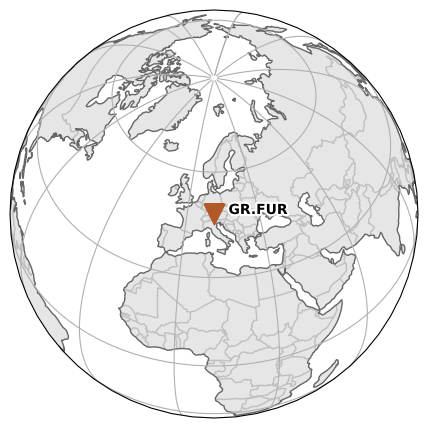

In [5]:
from obspy import read, read_inventory

base_url = "https://raw.githubusercontent.com/seismo-live/seismo_live/master/notebooks/Ambient%20Seismic%20Noise/data/"
st = read(base_url + "GR.FUR..BHN.D.2015.361")
inv = read_inventory(base_url + "station_FUR.stationxml")

print(st)
print(inv)
inv.plot(projection="ortho");

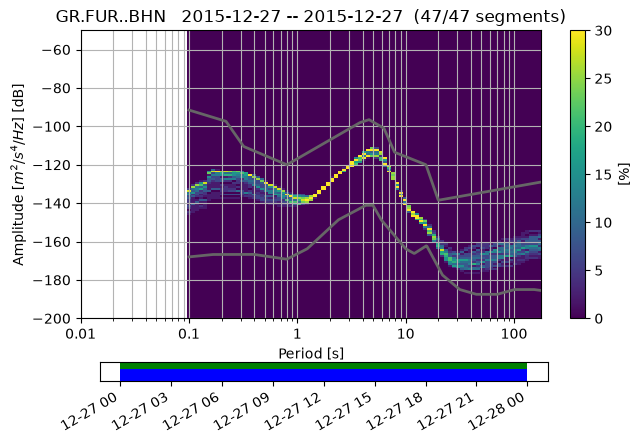

In [6]:
from obspy.signal import PPSD

tr = st[0]
ppsd = PPSD(stats=tr.stats, metadata=inv)

ppsd.add(tr)
ppsd.plot()

In [9]:
from obspy.signal import PPSD

ppsd = PPSD.load_npz("data/PPSD_FUR_HHN.npz", allow_pickle=True)

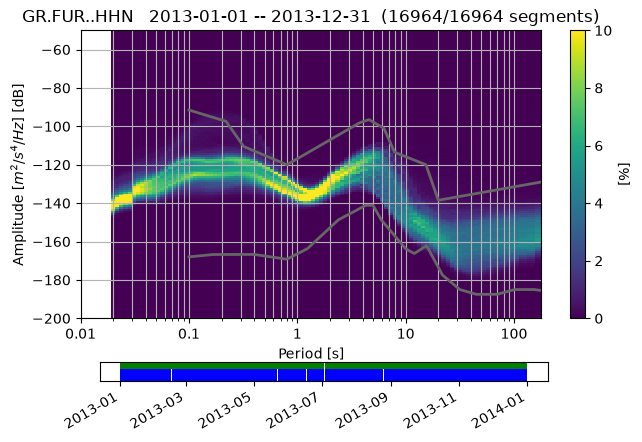

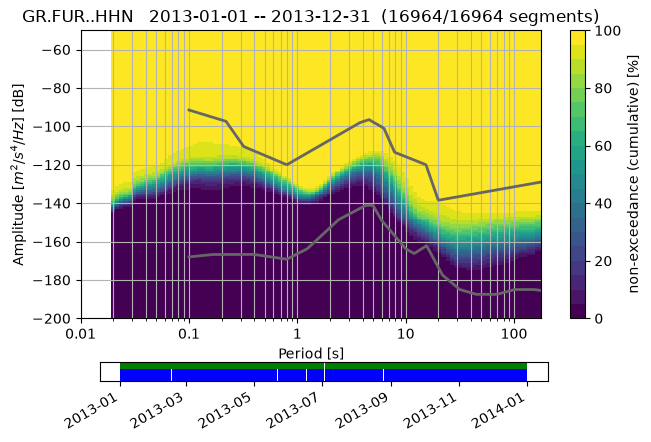

In [10]:
ppsd.plot(max_percentage=10)
ppsd.plot(cumulative=True)

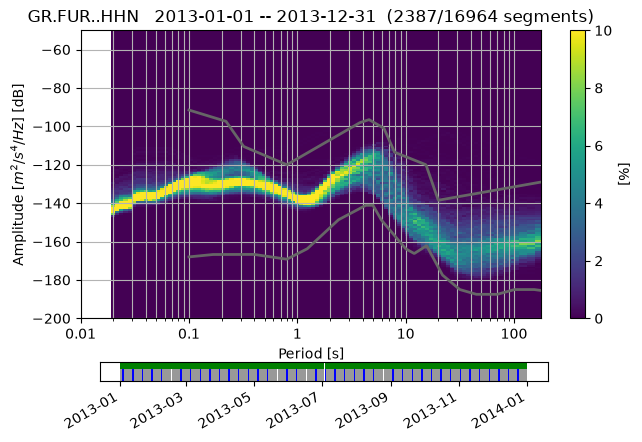

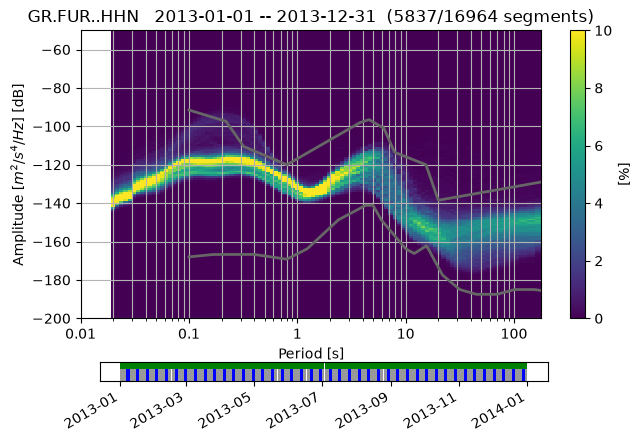

In [11]:
ppsd.calculate_histogram(time_of_weekday=[(-1, 0, 2), (-1, 22, 24)])
ppsd.plot(max_percentage=10)
ppsd.calculate_histogram(time_of_weekday=[(-1, 8, 16)])
ppsd.plot(max_percentage=10)

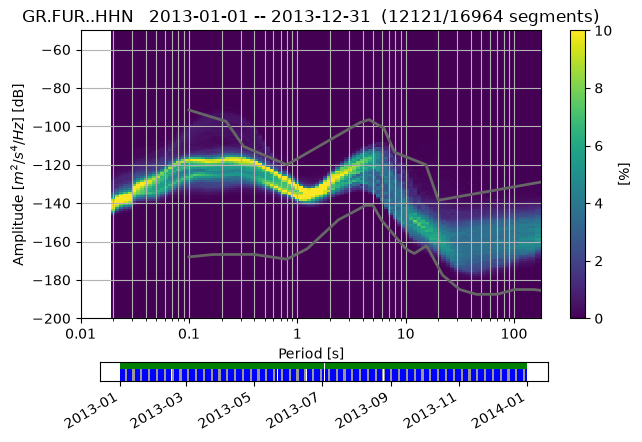

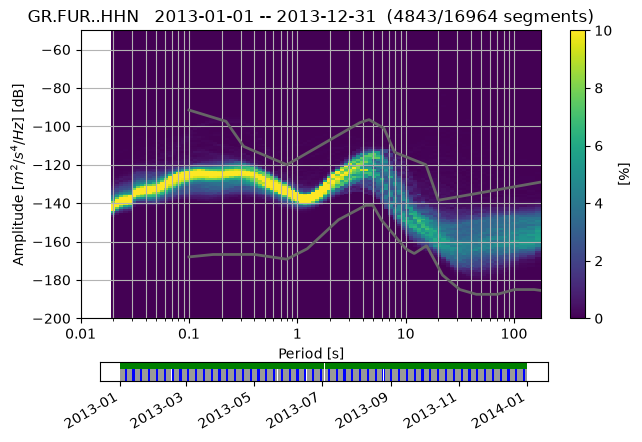

In [12]:
ppsd.calculate_histogram(time_of_weekday=[(1, 0, 24), (2, 0, 24), (3, 0, 24), (4, 0, 24), (5, 0, 24)])
ppsd.plot(max_percentage=10)
ppsd.calculate_histogram(time_of_weekday=[(6, 0, 24), (7, 0, 24)])
ppsd.plot(max_percentage=10)

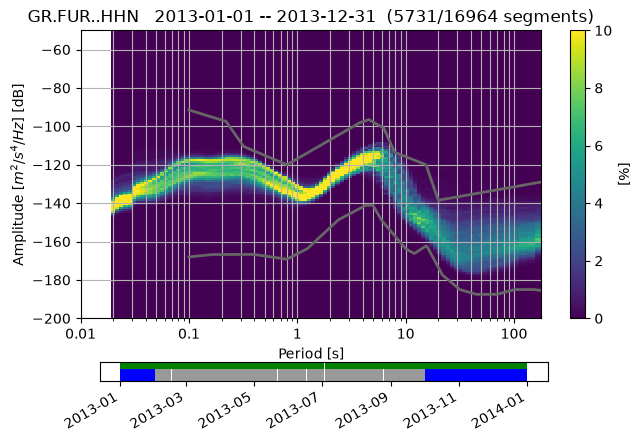

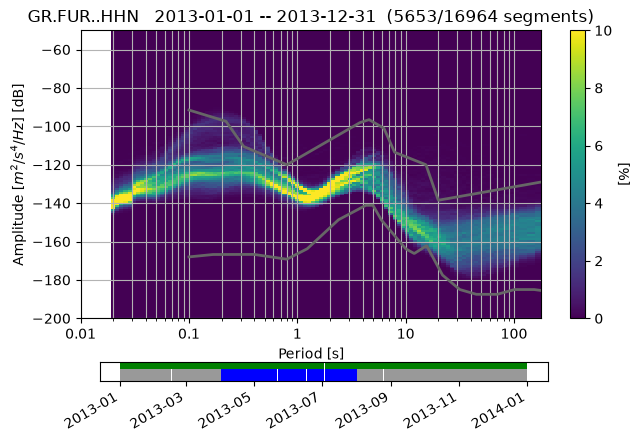

In [13]:
ppsd.calculate_histogram(month=[10, 11, 12, 1])
ppsd.plot(max_percentage=10)
ppsd.calculate_histogram(month=[4, 5, 6, 7])
ppsd.plot(max_percentage=10)